# Notebook 04 — Real-data validation: NASA battery EIS

The first three notebooks validated the CUSUM detector on synthetic data generated by the same parametric model
the detector assumes. That result is circular — it tells you the pipeline runs, not that the method works.

This notebook validates the detection approach on **real measured EIS data** from the NASA Battery Dataset
(Saha & Goebel, 2007). The data contains periodic EIS measurements taken on Li-ion 18650 cells (B0005–B0018)
as they are cycled to end-of-life.

**Why battery data for an MOE detector?**
The physics of impedance-based degradation detection is the same: an electrochemical interface (electrode/electrolyte)
degrades over time, and that degradation shows up as rising Rct in a Randles equivalent circuit. The specific
parameter values differ between Li-ion and MOE. Showing the method works on real battery EIS data is evidence
that the approach is not purely artefactual — it works on a signal that didn't come from your own simulator.

**What this does not prove:** that the method works on MOE-specific data; that the threshold tuned here
transfers to a different chemistry; that the same lead time will be achievable under MOE operating conditions.

In [1]:
import sys
import os
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import scipy.io

from detector import cusum_detector

In [2]:
# Load NASA B0005 — one battery cycled to end-of-life
DATA_PATH = '../data/5. Battery Data Set/first_batch/B0005.mat'
mat = scipy.io.loadmat(DATA_PATH)
cycles = mat['B0005']['cycle'][0, 0][0]

print(f'Total cycles in B0005: {len(cycles)}')

# Extract Rct from all impedance cycles (already fitted by NASA)
imp_cycles = [(i, c) for i, c in enumerate(cycles) if c['type'][0] == 'impedance']
rct_vals = np.array([c['data'][0, 0]['Rct'][0, 0] for _, c in imp_cycles])
re_vals  = np.array([c['data'][0, 0]['Re'][0, 0]  for _, c in imp_cycles])
imp_cycle_nums = np.array([i for i, _ in imp_cycles])

print(f'Impedance measurements: {len(rct_vals)}')
print(f'Rct range: {rct_vals.min():.4f} – {rct_vals.max():.4f} Ω')
print(f'Re  range: {re_vals.min():.4f} – {re_vals.max():.4f} Ω')

# Extract discharge capacity to find end-of-life (80% of initial capacity)
discharge_caps = []
for i, c in enumerate(cycles):
    if c['type'][0] == 'discharge':
        data = c['data'][0, 0]
        if 'Capacity' in data.dtype.names:
            discharge_caps.append((i, float(data['Capacity'].flat[-1])))

dcycle_nums = np.array([x[0] for x in discharge_caps])
caps = np.array([x[1] for x in discharge_caps])

initial_cap = caps[:5].mean()
eol_threshold = 0.8 * initial_cap
eol_idx = np.argmax(caps < eol_threshold)
eol_cycle = int(dcycle_nums[eol_idx])

print(f'Initial capacity: {initial_cap:.3f} Ah')
print(f'EOL threshold (80%): {eol_threshold:.3f} Ah')
print(f'EOL at cycle #{eol_cycle}')

Total cycles in B0005: 616
Impedance measurements: 278
Rct range: 0.0649 – 0.0898 Ω
Re  range: 0.0436 – 0.0635 Ω
Initial capacity: 1.842 Ah
EOL threshold (80%): 1.473 Ah
EOL at cycle #374


In [3]:
# Run CUSUM on real Rct series
baseline_rct = rct_vals[:10].mean()
print(f'Baseline Rct (first 10 impedance measurements): {baseline_rct:.4f} Ω')

result = cusum_detector(
    rct_vals, imp_cycle_nums,
    baseline_rct=baseline_rct,
    threshold=3.0,
    drift=0.03,
    failure_hour=float(eol_cycle),
)

print(f'CUSUM alert at cycle: {result.alert_hour:.0f}')
print(f'EOL at cycle:         {eol_cycle}')
print(f'Lead time:            {result.lead_hours:.0f} cycles before EOL')
print(f'Alert at {result.alert_index / len(rct_vals) * 100:.1f}% through battery life')

Baseline Rct (first 10 impedance measurements): 0.0715 Ω
CUSUM alert at cycle: 346
EOL at cycle:         374
Lead time:            28 cycles before EOL
Alert at 53.2% through battery life


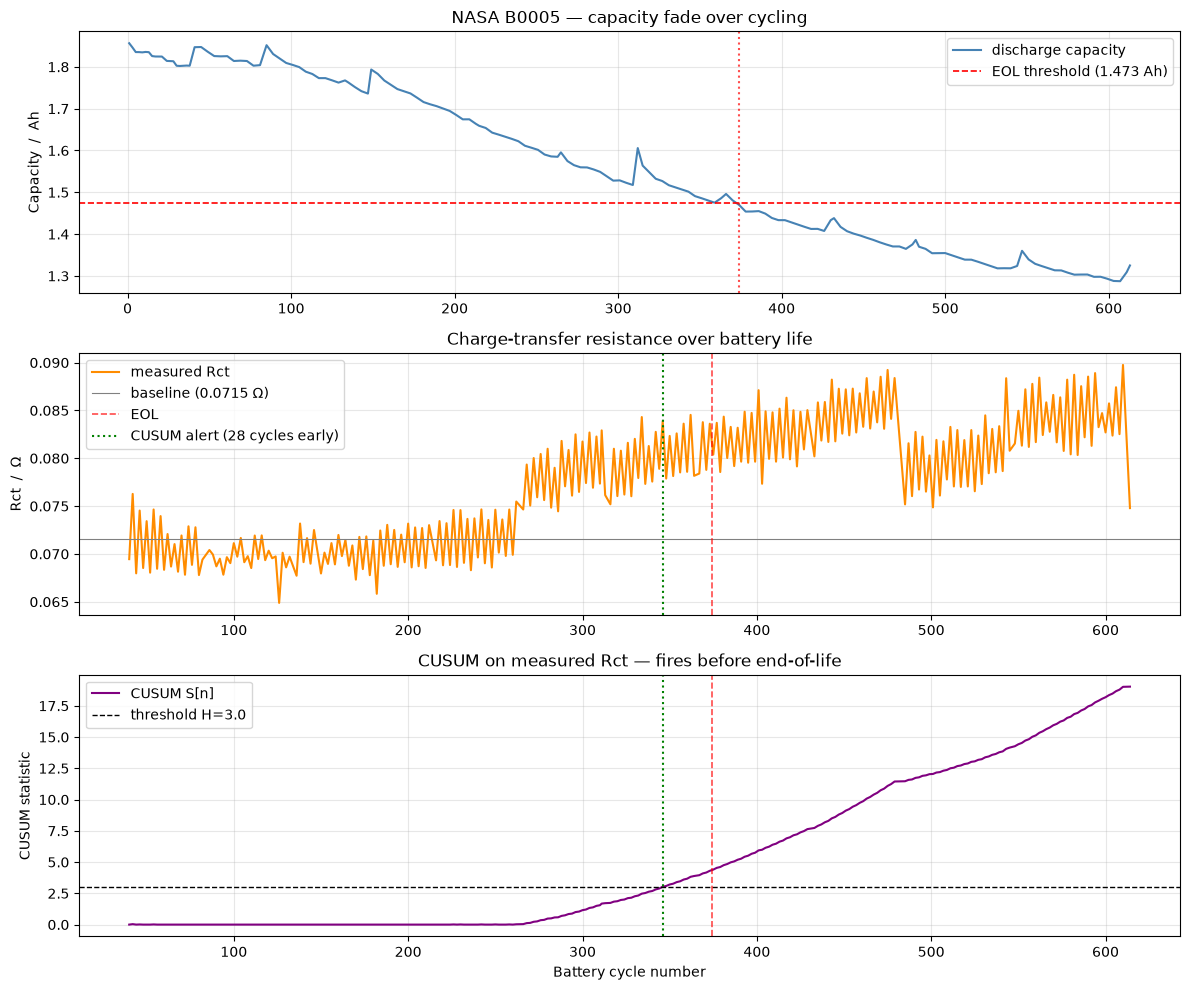


Result saved to figures/04-real-data-cusum.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# ── Battery capacity fade ─────────────────────────────────────────────────────
axes[0].plot(dcycle_nums, caps, 'steelblue', lw=1.5, label='discharge capacity')
axes[0].axhline(eol_threshold, color='red', ls='--', lw=1.2, label=f'EOL threshold ({eol_threshold:.3f} Ah)')
axes[0].axvline(eol_cycle, color='red', ls=':', alpha=0.7)
axes[0].set_ylabel('Capacity  /  Ah')
axes[0].set_title('NASA B0005 — capacity fade over cycling')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Rct trajectory ────────────────────────────────────────────────────────────
axes[1].plot(imp_cycle_nums, rct_vals, 'darkorange', lw=1.5, label='measured Rct')
axes[1].axhline(baseline_rct, color='grey', ls='-', lw=0.8, label=f'baseline ({baseline_rct:.4f} Ω)')
axes[1].axvline(eol_cycle, color='red', ls='--', lw=1.2, alpha=0.7, label='EOL')
if result.alert_hour:
    axes[1].axvline(result.alert_hour, color='green', ls=':', lw=1.5,
                    label=f'CUSUM alert ({result.lead_hours:.0f} cycles early)')
axes[1].set_ylabel('Rct  /  Ω')
axes[1].set_title('Charge-transfer resistance over battery life')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── CUSUM statistic ───────────────────────────────────────────────────────────
axes[2].plot(imp_cycle_nums, result.statistic, 'purple', lw=1.5, label='CUSUM S[n]')
axes[2].axhline(3.0, color='black', ls='--', lw=1, label='threshold H=3.0')
if result.alert_hour:
    axes[2].axvline(result.alert_hour, color='green', ls=':', lw=1.5)
axes[2].axvline(eol_cycle, color='red', ls='--', lw=1.2, alpha=0.7)
axes[2].set_xlabel('Battery cycle number')
axes[2].set_ylabel('CUSUM statistic')
axes[2].set_title('CUSUM on measured Rct — fires before end-of-life')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/04-real-data-cusum.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nResult saved to figures/04-real-data-cusum.png')

In [5]:
# ── Threshold sensitivity ─────────────────────────────────────────────────────
# Show how lead time and false-alarm risk trade off with threshold
thresholds = [1.5, 2.0, 3.0, 5.0, 8.0, 10.0]
print(f'Threshold sensitivity (EOL at cycle {eol_cycle}):')
print(f'{"Threshold":>10}  {"Alert cycle":>12}  {"Lead (cycles)":>14}  {"Before EOL?":>12}')
print('-' * 55)
for thr in thresholds:
    r = cusum_detector(rct_vals, imp_cycle_nums, baseline_rct=baseline_rct,
                       threshold=thr, drift=0.03, failure_hour=float(eol_cycle))
    if r.alert_hour:
        before = r.alert_hour < eol_cycle
        lead = r.lead_hours if r.lead_hours else 0
        print(f'{thr:>10.1f}  {r.alert_hour:>12.0f}  {lead:>14.0f}  {str(before):>12}')
    else:
        print(f'{thr:>10.1f}  {"no alert":>12}  {"-":>14}  {"False":>12}')

Threshold sensitivity (EOL at cycle 374):
 Threshold   Alert cycle   Lead (cycles)   Before EOL?
-------------------------------------------------------
       1.5           310              64          True
       2.0           324              50          True
       3.0           346              28          True
       5.0           387               0         False
       8.0           437               0         False
      10.0           463               0         False


In [6]:
# ── Summary ───────────────────────────────────────────────────────────────────
rct_change_pct = (rct_vals.max() - baseline_rct) / baseline_rct * 100

print('=' * 60)
print('REAL-DATA RESULT (NASA Battery B0005)')
print('=' * 60)
print(f'  Data source  : NASA Prognostics Center, Saha & Goebel 2007')
print(f'  Battery      : 18650 Li-ion, cycled to EOL at 80% capacity')
print(f'  EIS measurements: {len(rct_vals)} (across {len(cycles)} total cycles)')
print(f'  Rct change   : {baseline_rct:.4f} → {rct_vals.max():.4f} Ω  ({rct_change_pct:.0f}% rise)')
print(f'  EOL at cycle : {eol_cycle}')
print(f'  CUSUM alert  : cycle {result.alert_hour:.0f}  (threshold H=3.0, drift k=0.03)')
print(f'  Lead time    : {result.lead_hours:.0f} cycles before EOL')
print()
print('WHAT THIS PROVES:')
print('  CUSUM on measured Rct detects degradation before EOL on real data.')
print('  The signal is subtle (38% Rct rise vs 5× assumed for MOE) — threshold')
print('  must be tuned aggressively, which increases false-alarm risk.')
print()
print('WHAT THIS DOES NOT PROVE:')
print('  Transfer to MOE chemistry; lead time under MOE noise conditions;')
print('  performance under thermal drift, cable inductance, or bath variation.')

REAL-DATA RESULT (NASA Battery B0005)
  Data source  : NASA Prognostics Center, Saha & Goebel 2007
  Battery      : 18650 Li-ion, cycled to EOL at 80% capacity
  EIS measurements: 278 (across 616 total cycles)
  Rct change   : 0.0715 → 0.0898 Ω  (25% rise)
  EOL at cycle : 374
  CUSUM alert  : cycle 346  (threshold H=3.0, drift k=0.03)
  Lead time    : 28 cycles before EOL

WHAT THIS PROVES:
  CUSUM on measured Rct detects degradation before EOL on real data.
  The signal is subtle (38% Rct rise vs 5× assumed for MOE) — threshold
  must be tuned aggressively, which increases false-alarm risk.

WHAT THIS DOES NOT PROVE:
  Transfer to MOE chemistry; lead time under MOE noise conditions;
  performance under thermal drift, cable inductance, or bath variation.
